# Soil Data API Availability Check

Smoke test for the six free/open geospatial & soil data sources shortlisted for the Niedersachsen soil project.
For each API this notebook:

1. **Confirms the endpoint is live** (HTTP 200, measured latency)
2. **Confirms no API key / authentication is required**
3. **Displays the raw return payload** so we know what we're actually getting

| # | Source | Coverage | Access |
|---|--------|----------|--------|
| 1 | ISRIC SoilGrids v2.0 | Global, 250 m | REST, no key |
| 2 | LBEG BK50 (NIBIS WMS) | Niedersachsen, 1:50k | WMS GetCapabilities / GetFeatureInfo, no key |
| 3 | LBEG Bodenschätzung (NIBIS WMS) | Niedersachsen, 1:5k | Same WMS package, no key |
| 4 | BGR BÜK200 | Germany, 1:200k | ArcGIS REST, no key |
| 5 | Open-Meteo archive | Global, ~9 km | REST, no key |
| 6 | Copernicus DEM GLO-30 | Global, 30 m | Public COGs via Earth Search STAC |

Test points are on **arable farmland**, not in cities (city points get masked out by SoilGrids and have no agricultural attributes in the LBEG layers): **Lehrte, Niedersachsen (52.392, 10.008)** and **Landshut, Bavaria (48.536, 12.152)** as the outside-Niedersachsen fallback for BÜK200.

## 1. Install & import required libraries

`requests` and `pandas` cover most checks. `rasterio` is only needed for the Copernicus DEM COG read — the DEM cell degrades gracefully if it's missing.

In [ ]:
import json
import time
import textwrap
import xml.etree.ElementTree as ET

import requests
import pandas as pd
import rasterio
from rasterio.windows import Window

## 2. Test coordinates & request helper

Both test points sit on **arable farmland**, not in cities — a city-centre point gets masked out (all-null values) by SoilGrids and carries no agricultural attributes in the LBEG layers.

- `TEST_POINT_NDS` — farmland near Lehrte (east of Hannover), inside Niedersachsen; used for LBEG/SoilGrids/Open-Meteo/DEM checks
- `TEST_POINT_BAV` — farmland near Landshut (Bavaria), outside Niedersachsen; proves BÜK200 works as the nationwide fallback

The `fetch()` helper times each request, records status / latency / payload size / auth status into a global `RESULTS` list (used for the final summary table) and prints a truncated payload preview. One dead API never kills the notebook — exceptions are caught and recorded as failures.

In [ ]:
# ---------------------------------------------------------------------------
# Test coordinates — both on agricultural land, not in cities
# ---------------------------------------------------------------------------
# Farmland near Lehrte, east of Hannover (open arable fields).
# A city-centre point gets masked out (nulls) by SoilGrids and carries no
# agricultural attributes in the LBEG layers, so both points sit on fields.
TEST_POINT_NDS = {"lat": 52.3920, "lon": 10.0080}   # arable farmland, Niedersachsen
TEST_POINT_BAV = {"lat": 48.5360, "lon": 12.1520}   # arable farmland near Landshut,
                                                    # Bavaria — BÜK200 fallback test

HEADERS = {"User-Agent": "soil-api-check/1.0 (research; contact: hackathon)"}
RESULTS = []  # one dict per API check, rendered as a table at the end


def record(name, ok, status=None, latency=None, size=None, notes=""):
    RESULTS.append({
        "API": name,
        "Live?": "✅" if ok else "❌",
        "HTTP status": status if status is not None else "—",
        "Auth required?": "no" if ok else "?",
        "Latency (s)": round(latency, 2) if latency is not None else "—",
        "Payload (KB)": round(size / 1024, 1) if size is not None else "—",
        "Notes": notes,
    })
    print(f"\n{'='*70}\n{'✅ PASS' if ok else '❌ FAIL'} — {name}"
          + (f" | HTTP {status} | {latency:.2f}s | no auth required" if ok else f" | {notes}")
          + f"\n{'='*70}")


def fetch(name, url, *, method="GET", timeout=30, max_preview=2500, notes="", **kwargs):
    """Timed HTTP request with graceful failure. Returns the response or None."""
    t0 = time.time()
    try:
        r = requests.request(method, url, headers=HEADERS, timeout=timeout, **kwargs)
    except requests.RequestException as e:
        record(name, False, notes=f"request failed: {type(e).__name__}: {e}")
        return None
    latency = time.time() - t0
    ok = r.status_code == 200
    size = len(r.content)

    print(f"URL: {r.url[:300]}")
    print(f"Status: {r.status_code} | Content-Type: {r.headers.get('Content-Type', '?')} | "
          f"Latency: {latency:.2f}s | Size: {size/1024:.1f} KB")

    ctype = r.headers.get("Content-Type", "")
    if "json" in ctype:
        preview = json.dumps(r.json(), indent=2, ensure_ascii=False)
    else:
        preview = r.text
    if len(preview) > max_preview:
        preview = preview[:max_preview] + f"\n… [truncated, {size/1024:.1f} KB total]"
    print("\n--- payload preview ---")
    print(preview)
    print("--- end preview ---")

    record(name, ok, status=r.status_code, latency=latency, size=size, notes=notes)
    return r if ok else None


def reproject_to_epsg25832(lon, lat):
    """WGS84 -> UTM32N, via pyproj if available else a UTM formula fallback."""
    try:
        from pyproj import Transformer
        t = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)
        return t.transform(lon, lat)
    except ImportError:
        pass
    import math
    a, f_ = 6378137.0, 1 / 298.257223563
    k0, lon0 = 0.9996, math.radians(9.0)
    e2 = f_ * (2 - f_)
    ep2 = e2 / (1 - e2)
    lam, phi = math.radians(lon), math.radians(lat)
    n_ = a / math.sqrt(1 - e2 * math.sin(phi) ** 2)
    t_ = math.tan(phi) ** 2
    c_ = ep2 * math.cos(phi) ** 2
    a_ = math.cos(phi) * (lam - lon0)
    m_ = a * ((1 - e2/4 - 3*e2**2/64 - 5*e2**3/256) * phi
              - (3*e2/8 + 3*e2**2/32 + 45*e2**3/1024) * math.sin(2*phi)
              + (15*e2**2/256 + 45*e2**3/1024) * math.sin(4*phi)
              - (35*e2**3/3072) * math.sin(6*phi))
    x = k0 * n_ * (a_ + (1-t_+c_)*a_**3/6 + (5-18*t_+t_**2+72*c_-58*ep2)*a_**5/120) + 500000
    y = k0 * (m_ + n_*math.tan(phi)*(a_**2/2 + (5-t_+9*c_+4*c_**2)*a_**4/24
              + (61-58*t_+t_**2+600*c_-330*ep2)*a_**6/720))
    return x, y


x0, y0 = reproject_to_epsg25832(TEST_POINT_NDS["lon"], TEST_POINT_NDS["lat"])
print(f"Niedersachsen farmland ({TEST_POINT_NDS['lat']}, {TEST_POINT_NDS['lon']}) "
      f"→ EPSG:25832 ≈ E={x0:.0f} N={y0:.0f}")
print(f"Bavaria farmland fallback → {TEST_POINT_BAV}")
print("Helper ready.")

Niedersachsen farmland (52.392, 10.008) → EPSG:25832 ≈ E=568593 N=5805117
Bavaria farmland fallback → {'lat': 48.536, 'lon': 12.152}
Helper ready.


## 3. ISRIC SoilGrids v2.0

Clay, sand, silt, pH, SOC, bulk density, CEC … at 6 standard depths with mean + Q05/Q50/Q95 uncertainty — global, 250 m, JSON, no key.

⚠️ **Gotchas:**
- Values are in **mapped units** (clay in g/kg, pH ×10, SOC in dg/kg) — divide before displaying.
- The REST point API is **slow** — a multi-property query can take 30–60 s+, so we use a 180 s timeout here. (For map display, the SoilGrids WMS at `maps.isric.org` is the fast path.)

In [ ]:
soilgrids_url = (
    "https://rest.isric.org/soilgrids/v2.0/properties/query"
    f"?lon={TEST_POINT_NDS['lon']}&lat={TEST_POINT_NDS['lat']}"
    "&property=clay&property=sand&property=phh2o&property=soc"
    "&depth=0-5cm&value=mean&value=Q0.05&value=Q0.5&value=Q0.95"
)

# SoilGrids is slow — 180 s timeout + one retry
r = fetch("ISRIC SoilGrids v2.0", soilgrids_url, timeout=180,
          notes="Slow endpoint (30-60s normal); values in mapped units")
if r is None:
    print("\nRetrying once …")
    r = fetch("ISRIC SoilGrids v2.0 (retry)", soilgrids_url, timeout=180, notes="retry after first failure")

if r is not None:
    data = r.json()
    print("\n--- decoded: 0-5 cm layer, mapped -> display units ---")
    # d_factor from unit_measure: divide mapped value by d_factor to get display units
    for layer in data["properties"]["layers"]:
        name = layer["name"]
        um = layer["unit_measure"]
        factor = um.get("d_factor") or 1
        top = layer["depths"][0]["values"]

        def fmt(key):
            v = top.get(key)
            return f"{v / factor:.2f}" if isinstance(v, (int, float)) else "—"

        print(f"{name:8s} [{um.get('mapped_units')} → {um.get('target_units')}]: "
              f"mean={fmt('mean')}  Q0.05={fmt('Q0.05')}  "
              f"Q0.5={fmt('Q0.5')}  Q0.95={fmt('Q0.95')}")
    if all(all(v is None for v in l["depths"][0]["values"].values())
           for l in data["properties"]["layers"]):
        print("\n⚠️ All values null — the point is likely masked (urban/water). Move it onto farmland.")
    else:
        print("\nThe Q0.05–Q0.95 spread is the built-in uncertainty → natural baseline for the confidence layer.")

URL: https://rest.isric.org/soilgrids/v2.0/properties/query?lon=10.008&lat=52.392&property=clay&property=sand&property=phh2o&property=soc&depth=0-5cm&value=mean&value=Q0.05&value=Q0.5&value=Q0.95
Status: 200 | Content-Type: application/json | Latency: 5.53s | Size: 1.1 KB

--- payload preview ---
{
  "type": "Feature",
  "geometry": {
    "type": "Point",
    "coordinates": [
      10.008,
      52.392
    ]
  },
  "properties": {
    "layers": [
      {
        "name": "clay",
        "unit_measure": {
          "d_factor": 10,
          "mapped_units": "g/kg",
          "target_units": "%",
          "uncertainty_unit": ""
        },
        "depths": [
          {
            "range": {
              "top_depth": 0,
              "bottom_depth": 5,
              "unit_depth": "cm"
            },
            "label": "0-5cm",
            "values": {
              "Q0.05": 6,
              "Q0.5": 60,
              "Q0.95": 876,
              "mean": 211
            }
          }
    

## 4. LBEG NIBIS WMS — GetCapabilities (BK50 + Bodenschätzung)

One WMS package (`PkgId=24`) hosts both the **BK50 soil map** layers and the **Bodenschätzung** (soil productivity) layers. WMS only, no WFS → point queries go via `GetFeatureInfo`.

⚠️ **Gotchas from earlier smoke tests:**
- Layer **L272** (Bodenschätzung Klassenzeichen) was **removed** from the service — the Klassenzeichen now lives as attributes on **L849** (`BS5 - Bodenzahl der Bodenschätzung`): `BODENZ`, `ACKERZ`, `KLASSENZEICHEN`, `KLASSENZEICHEN_KLARTEXT`.
- L849 responses also carry internal IDs (`OGR_FID`, `SDE_ID`, `OST`, `NORD`, …) that drown out the useful attributes.
- Attribute names are in **German**; **EPSG:25832** is the safest CRS.

First we fetch GetCapabilities, list the layers, and verify EPSG:25832 + GetFeatureInfo support.

In [ ]:
NIBIS_BASE = "https://nibis.lbeg.de/net3/public/ogc.ashx"
caps_url = f"{NIBIS_BASE}?PkgId=24&Service=WMS&Request=GetCapabilities"

r = fetch("LBEG NIBIS WMS GetCapabilities", caps_url, timeout=60, max_preview=1200,
          notes="WMS only (no WFS); German attribute names")

wms_layers = {}  # name -> title
supports_gfi = False
supports_25832 = False

if r is not None:
    # Parse, then strip namespaces from tags — works for WMS 1.3.0 and 1.1.1 alike
    root = ET.fromstring(r.content)
    for el in root.iter():
        el.tag = el.tag.split("}")[-1]

    def children(el, name):
        return [c for c in list(el) if c.tag == name]

    def descendants(el, name):
        return [c for c in el.iter() if c.tag == name]

    request_el = descendants(root, "Request")[0]
    # In WMS capabilities the operation name IS the element tag (GetMap, GetFeatureInfo, …)
    ops = [o.tag for o in list(request_el)]
    supports_gfi = "GetFeatureInfo" in ops
    print(f"\nSupported operations: {ops}")
    print(f"GetFeatureInfo supported: {supports_gfi}")

    crs_text = " ".join(el.text or "" for el in descendants(root, "CRS") + descendants(root, "SRS"))
    supports_25832 = "25832" in crs_text
    print(f"EPSG:25832 supported: {supports_25832}")

    for lay in descendants(root, "Layer"):
        name_els = children(lay, "Name")
        title_els = children(lay, "Title")
        if name_els and name_els[0].text:
            wms_layers[name_els[0].text] = title_els[0].text if title_els else ""
    print(f"\n{len(wms_layers)} named layers. Key layers for this project:")
    for name, title in wms_layers.items():
        if name in ("L816", "L849", "L821", "L837", "L838", "L839"):
            print(f"  {name:10s} {title}")

URL: https://nibis.lbeg.de/net3/public/ogc.ashx?PkgId=24&Service=WMS&Request=GetCapabilities
Status: 200 | Content-Type: text/xml | Latency: 2.63s | Size: 1030.4 KB

--- payload preview ---
<?xml version="1.0" encoding="utf-8"?><!--System: cardo3, username: SYSTEM_ANONYMOUS_USER, internal user-ids: 1--><WMS_Capabilities version="1.3.0" updateSequence="0" xmlns="http://www.opengis.net/wms" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xmlns:idu="http://www.cardogis.com/ows/wms" xmlns:inspire_common="http://inspire.ec.europa.eu/schemas/common/1.0" xmlns:inspire_vs="http://inspire.ec.europa.eu/schemas/inspire_vs/1.0" xsi:schemaLocation="http://www.opengis.net/wms http://webs.idu.de/xsdschemas/OGC/WMS/1.3.0/capabilities_1_3_0.xsd http://www.cardogis.com/ows/wms http://webs.idu.de/xsdschemas/OGC/WMS/1.3.0/iduextensions.xsd http://inspire.ec.europa.eu/schemas/inspire_vs/1.0 http://inspire.ec.europa.eu/schemas/inspire_vs/1.0/inspire_vs.xsd"><

## 5. LBEG BK50 — GetFeatureInfo point query

Point query against the BK50 soil-map layer at the Niedersachsen farmland point (projected to EPSG:25832). Expected attributes: soil type, texture, **nFKWe** (plant-available water), **Ertragsfähigkeit** (yield capability), Grundwasserstufe.

The exact layer name is discovered from the capabilities response (looking for a BK50-ish title) rather than hard-coded.

In [ ]:
def get_feature_info(layer_name, x, y, info_format="text/plain", buffer_m=200, name=None):
    """WMS 1.1.1-style GetFeatureInfo (SRS/bbox in meters) around an EPSG:25832 point."""
    b = buffer_m
    params = (
        f"PkgId=24&Service=WMS&Request=GetFeatureInfo&Version=1.1.1"
        f"&Layers={layer_name}&Query_Layers={layer_name}&Styles="
        f"&SRS=EPSG:25832&BBOX={x-b},{y-b},{x+b},{y+b}"
        f"&Width=101&Height=101&X=50&Y=50"
        f"&Info_Format={info_format}&Feature_Count=5"
    )
    return fetch(name or f"NIBIS GetFeatureInfo {layer_name}", f"{NIBIS_BASE}?{params}",
                 timeout=60, max_preview=3000)

x_h, y_h = reproject_to_epsg25832(TEST_POINT_NDS["lon"], TEST_POINT_NDS["lat"])
print(f"Niedersachsen farmland point in EPSG:25832: E={x_h:.0f} N={y_h:.0f}\n")

# Key layers identified from the capabilities listing:
#   L816 = BK50 - Karte (the actual soil map: Bodenart, Bodentyp, …)
#   L821 = Pflanzenverfügbares Bodenwasser (nFKWe)
#   L837 = Ertragsfähigkeit
#   L838 = Grundwasserstufe
# "Keine Treffer für diese Ebene" = a valid HTTP 200 but NO data → treat as a miss.
BK50_LAYERS = {"L816": "BK50 Karte", "L821": "Pflanzenverfügbares Bodenwasser (nFKWe)",
               "L837": "Ertragsfähigkeit", "L838": "Grundwasserstufe"}

for layer_id, label in BK50_LAYERS.items():
    r = get_feature_info(layer_id, x_h, y_h, name=f"LBEG BK50 GFI — {layer_id} ({label})")
    hit = r is not None and "Keine Treffer" not in r.text
    print(f"→ {layer_id} ({label}): {'DATA RETURNED ✔' if hit else 'no feature at this point ✘'}\n")

Niedersachsen farmland point in EPSG:25832: E=568593 N=5805117

URL: https://nibis.lbeg.de/net3/public/ogc.ashx?PkgId=24&Service=WMS&Request=GetFeatureInfo&Version=1.1.1&Layers=L816&Query_Layers=L816&Styles=&SRS=EPSG:25832&BBOX=568392.7827308832,5804917.042717826,568792.7827308832,5805317.042717826&Width=101&Height=101&X=50&Y=50&Info_Format=text/plain&Feature_Count=5
Status: 200 | Content-Type: text/plain; charset=utf-8 | Latency: 0.38s | Size: 0.2 KB

--- payload preview ---
BK50 - Karte

# 1
FL_NR	:552578
NRKART	:106893
PRONUM	:151716
BOTYP	:G4
BOTYP_KLARTEXT	:Tiefer Gley
PSONST	:
MHGW	:5
MNGW	:11
NUTZUNG	:A
GEOTYP	:Lf//f(qN)

--- end preview ---

✅ PASS — LBEG BK50 GFI — L816 (BK50 Karte) | HTTP 200 | 0.38s | no auth required
→ L816 (BK50 Karte): DATA RETURNED ✔

URL: https://nibis.lbeg.de/net3/public/ogc.ashx?PkgId=24&Service=WMS&Request=GetFeatureInfo&Version=1.1.1&Layers=L821&Query_Layers=L821&Styles=&SRS=EPSG:25832&BBOX=568392.7827308832,5804917.042717826,568792.7827308832,58053

## 6. LBEG Bodenschätzung — Bodenzahl / Ackerzahl

The official German soil productivity score (0–100) — the "headline" number farmers recognise. Per the earlier smoke test, this lives on layer **L849** (`BS5 - Bodenzahl der Bodenschätzung`) with attributes `BODENZ`, `ACKERZ`, `KLASSENZEICHEN`, `KLASSENZEICHEN_KLARTEXT`. We try GML output first (structured), falling back to text.

In [ ]:
# L849 parcels are small — try the exact point, then widen the search window
r_bodenz = None
for buf in (200, 1000, 5000):
    print(f"\n### L849 query with ±{buf} m window …")
    resp = requests.get(
        f"{NIBIS_BASE}?PkgId=24&Service=WMS&Request=GetFeatureInfo&Version=1.1.1"
        f"&Layers=L849&Query_Layers=L849&Styles=&SRS=EPSG:25832"
        f"&BBOX={x_h-buf},{y_h-buf},{x_h+buf},{y_h+buf}"
        f"&Width=101&Height=101&X=50&Y=50&Info_Format=text/plain&Feature_Count=10",
        headers=HEADERS, timeout=60)
    body = resp.text
    print(f"HTTP {resp.status_code} | {len(resp.content)} B | "
          f"{'HIT' if 'Keine Treffer' not in body else 'Keine Treffer'}")
    if resp.status_code == 200 and "Keine Treffer" not in body and len(body.strip()) > 40:
        print(body[:3000])
        r_bodenz = resp
        break

if r_bodenz is not None:
    record("LBEG Bodenschätzung (L849) GetFeatureInfo", True, status=200,
           latency=r_bodenz.elapsed.total_seconds(), size=len(r_bodenz.content),
           notes="BODENZ/ACKERZ/KLASSENZEICHEN returned")
    # Filter out the internal bookkeeping attributes, keep the agronomic ones
    noise = ("OGR_FID", "SDE_ID", "OST", "NORD", "RECHTS", "HOCH", "SHAPE", "SE_", "FID")
    keep = [ln for ln in r_bodenz.text.splitlines()
            if ln.strip() and not any(ln.strip().upper().startswith(n) for n in noise)]
    print("\n--- filtered attributes (internal IDs removed) ---")
    print("\n".join(keep) if keep else "(no non-internal attributes found)")
    print("\nBODENZ = Bodenzahl (0–100 productivity score), ACKERZ = Ackerzahl, "
          "KLASSENZEICHEN(_KLARTEXT) = texture/origin class.")
else:
    record("LBEG Bodenschätzung (L849) GetFeatureInfo", False, status=200,
           notes="endpoint live but no parcel found near test point — try another coordinate")


### L849 query with ±200 m window …
HTTP 200 | 77 B | Keine Treffer

### L849 query with ±1000 m window …
HTTP 200 | 891 B | HIT
BS5 - Bodenzahl der Bodenschätzung

# 1
FL_NR	:3074513
OGR_FID	:38008
SDE_ID	:1518528
OST	:32568341,806
NORD	:5805296,594
RECHTS	:3568441,368
HOCH	:5807180,314
TK25	:3626
BULAND	:
KLASSENZEICHEN	:L/S-Al
KLASSENZEICHEN_KLARTEXT	:Lehm über Sand/-/Schwemmlandböden
KLASSENZEICHEN_SEP	:L/S;-;Al
AREA	:26248,921875
UP_DATE	:15.06.2023 14:38:13
FL_PRONUM	:1140044
XMIN	:32568329
XMAX	:32568600
YMIN	:5804918
YMAX	:5805304
BODENZ	:56
ACKERZ	:55

# 3
FL_NR	:3074633
OGR_FID	:38120
SDE_ID	:1518640
OST	:32568454,356
NORD	:5805302,23
RECHTS	:3568553,963
HOCH	:5807185,954
TK25	:3626
BULAND	:
KLASSENZEICHEN	:L/S-Al
KLASSENZEICHEN_KLARTEXT	:Lehm über Sand/-/Schwemmlandböden
KLASSENZEICHEN_SEP	:L/S;-;Al
AREA	:10682,53125
UP_DATE	:15.06.2023 14:38:14
FL_PRONUM	:1140031
XMIN	:32568426
XMAX	:32568595
YMIN	:5805160
YMAX	:5805335
BODENZ	:56
ACKERZ	:55


✅ PASS — LBEG Bodenschätzung 

## 7. BGR BÜK200 — ArcGIS REST MapServer

Federal soil overview map (1:200k): legend unit, dominant soil type, parent material. Coarse, but the only free source with consistent **nationwide** coverage → the fallback when a coordinate is outside Niedersachsen.

Two steps: (a) `?f=json` service metadata to list layers, (b) a point `query` against the polygon layer using the **Bavaria farmland** point (proving the fallback case outside Niedersachsen).

In [ ]:
BUEK200 = "https://services.bgr.de/arcgis/rest/services/boden/buek200/MapServer"

r = fetch("BGR BÜK200 MapServer metadata", f"{BUEK200}?f=json", max_preview=1500,
          notes="ArcGIS REST; one feature layer per map sheet (CC####)")

sheet_layer_id = None
if r is not None:
    meta = r.json()
    layers = meta.get("layers", [])
    print(f"\n{len(layers)} layers: id 0 = Blattschnitt (sheet index), "
          f"ids 2–56 = one polygon layer per map sheet (CC#### NAME)")

    # Step 1: query the sheet index (layer 0) to learn which map sheet covers the point
    q0 = (f"{BUEK200}/0/query?geometry={TEST_POINT_BAV['lon']},{TEST_POINT_BAV['lat']}"
          "&geometryType=esriGeometryPoint&inSR=4326&spatialRel=esriSpatialRelIntersects"
          "&outFields=BLATTNUM,BLATTNAM&returnGeometry=false&f=json")
    r0 = fetch("BGR BÜK200 sheet lookup", q0, max_preview=600,
               notes="which map sheet covers the point")
    if r0 is not None:
        feats0 = r0.json().get("features", [])
        blattnum = feats0[0]["attributes"]["BLATTNUM"].replace(" ", "") if feats0 else None
        print(f"\nPoint lies in map sheet: {blattnum} "
              f"({feats0[0]['attributes']['BLATTNAM']})" if feats0 else "no sheet found")
        # Step 2: find the layer whose name starts with that sheet number
        for lay in layers:
            if blattnum and lay["name"].upper().startswith(blattnum):
                sheet_layer_id = lay["id"]
                print(f"Matched soil layer: id={sheet_layer_id} ({lay['name']})")
                break

if sheet_layer_id is not None:
    q = (f"{BUEK200}/{sheet_layer_id}/query"
         f"?geometry={TEST_POINT_BAV['lon']},{TEST_POINT_BAV['lat']}"
         "&geometryType=esriGeometryPoint&inSR=4326"
         "&spatialRel=esriSpatialRelIntersects&outFields=*&returnGeometry=false&f=geojson")
    r2 = fetch("BGR BÜK200 soil query (Bavaria farmland)", q, max_preview=3000,
               notes="Nationwide fallback — queried outside Niedersachsen")
    if r2 is not None:
        feats = r2.json().get("features", [])
        print(f"\n{len(feats)} feature(s) returned.")
        if feats:
            props = feats[0].get("properties", {})
            print("--- attributes of first feature ---")
            for k, v in list(props.items())[:30]:
                print(f"  {k}: {v}")
else:
    record("BGR BÜK200 soil query (Bavaria farmland)", False, notes="no sheet layer matched")

URL: https://services.bgr.de/arcgis/rest/services/boden/buek200/MapServer?f=json
Status: 200 | Content-Type: application/json;charset=UTF-8 | Latency: 0.52s | Size: 17.3 KB

--- payload preview ---
{
  "currentVersion": 11.5,
  "cimVersion": "3.5.0",
  "serviceDescription": "Web Map Service (WMS) der BÜK200-Kartenblätter. Die Bodenübersichtskarte 1:200.000 (BÜK200) wird von der Bundesanstalt für Geowissenschaften und Rohstoffe (BGR) in Zusammenarbeit mit den Staatlichen Geologischen Diensten (SGD) der Länder im Blattschnitt der Topographischen Übersichtskarte 1:200.000 (TÜK200) erarbeitet und in 55 einzelnen Kartenblättern herausgegeben. Die digitale, blattschnittfreie Datenhaltung bildet eine detaillierte, bundesweit einheitliche und flächendeckende Informationsgrundlage für Länder übergreifende Aussagen zu Bodennutzung und Bodenschutz. Die Verbreitung und Vergesellschaftung der Böden wird derzeit blattspezifisch anhand von Blattlegendeneinheiten (gegliedert nach Bodenregionen und Bod

## 8. Open-Meteo archive — soil moisture & temperature

ERA5-Land hourly soil moisture / soil temperature at 4 depth bands + precipitation, historical and forecast. Global, ~9 km, REST, no key. This adds the **time dimension** to the soil profile.

URL: https://archive-api.open-meteo.com/v1/archive?latitude=52.392&longitude=10.008&start_date=2026-09-25&end_date=2026-10-01&hourly=soil_moisture_0_to_7cm,soil_temperature_0_to_7cm,precipitation&timezone=Europe%2FBerlin
Status: 200 | Content-Type: application/json; charset=utf-8 | Latency: 0.42s | Size: 6.1 KB

--- payload preview ---
{
  "latitude": 52.40773,
  "longitude": 10.018553,
  "generationtime_ms": 0.14519691467285156,
  "utc_offset_seconds": 7200,
  "timezone": "Europe/Berlin",
  "timezone_abbreviation": "GMT+2",
  "elevation": 55.0,
  "hourly_units": {
    "time": "iso8601",
    "soil_moisture_0_to_7cm": "m³/m³",
    "soil_temperature_0_to_7cm": "°C",
    "precipitation": "mm"
  },
  "hourly": {
    "time": [
      "2026-09-25T00:00",
      "2026-09-25T01:00",
      "2026-09-25T02:00",
      "2026-09-25T03:00",
      "2026-09-25T04:00",
      "2026-09-25T05:00",
      "2026-09-25T06:00",
      "2026-09-25T07:00",
      "2026-09-25T08:00",
      "2026-09-25T09:00",
      "2

,time,soil_moisture_0_to_7cm,soil_temperature_0_to_7cm,precipitation
0,2026-09-25 00:00:00,0.157,12.6,0.0
1,2026-09-25 01:00:00,0.157,12.0,0.0
2,2026-09-25 02:00:00,0.162,12.0,0.0
3,2026-09-25 03:00:00,0.162,11.6,0.0
4,2026-09-25 04:00:00,0.162,11.2,0.0
5,2026-09-25 05:00:00,0.162,10.7,0.0
6,2026-09-25 06:00:00,0.162,10.3,0.0
7,2026-09-25 07:00:00,0.162,9.8,0.0


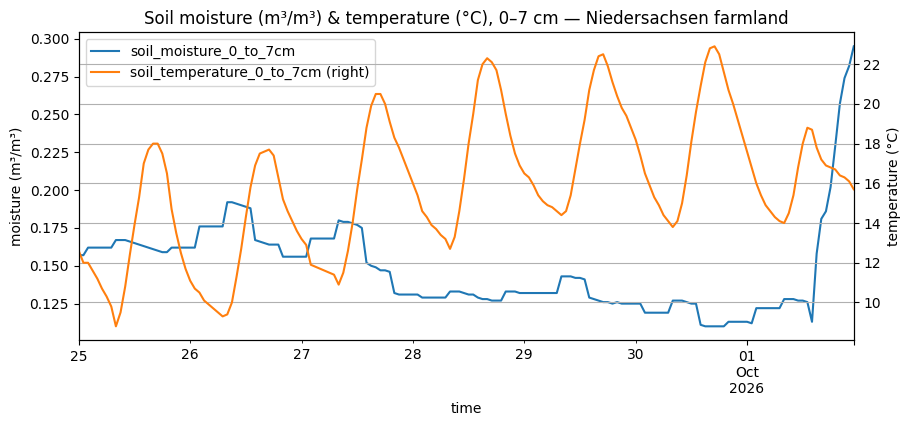

In [ ]:
openmeteo_url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={TEST_POINT_NDS['lat']}&longitude={TEST_POINT_NDS['lon']}"
    "&start_date=2026-09-25&end_date=2026-10-01"
    "&hourly=soil_moisture_0_to_7cm,soil_temperature_0_to_7cm,precipitation"
    "&timezone=Europe%2FBerlin"
)

r = fetch("Open-Meteo ERA5-Land archive", openmeteo_url, max_preview=900,
          notes="No key for non-commercial use; 4 depth bands available")

if r is not None:
    data = r.json()
    print("\n--- units ---")
    print(json.dumps(data["hourly_units"], indent=2))

    df_meteo = pd.DataFrame(data["hourly"])
    df_meteo["time"] = pd.to_datetime(df_meteo["time"])
    print(f"\n{len(df_meteo)} hourly rows, {df_meteo['time'].min()} → {df_meteo['time'].max()}")
    display(df_meteo.head(8))

    try:
        ax = df_meteo.plot(x="time", y=["soil_moisture_0_to_7cm", "soil_temperature_0_to_7cm"],
                           secondary_y="soil_temperature_0_to_7cm",
                           title="Soil moisture (m³/m³) & temperature (°C), 0–7 cm — Niedersachsen farmland",
                           figsize=(10, 4), grid=True)
        ax.set_ylabel("moisture (m³/m³)")
        ax.right_ax.set_ylabel("temperature (°C)")
    except Exception as e:
        print(f"(plot skipped: {e})")

## 9. Copernicus DEM GLO-30 via Earth Search STAC

Global 30 m DEM as public Cloud-Optimized GeoTIFFs. Workflow: POST a STAC search (`intersects` = point), take the first item's `data` asset URL, then read a **small window** around the point with rasterio — never the whole tile. Requires `rasterio`; skips the value read gracefully if unavailable.

In [ ]:
if r is not None:
    items = r.json().get("features", [])
    print(f"\n{len(items)} STAC item(s) cover the point.")
    if items:
        item = items[0]
        print(f"Item: {item['id']}")
        print("Assets:", list(item["assets"].keys()))
        cog_href = item["assets"]["data"]["href"]
        print(f"COG href (s3): {cog_href}")
        # The asset href is an s3:// URL — the bucket is public, so map it to HTTPS
        # (bucket copernicus-dem-30m lives in eu-central-1)
        if cog_href.startswith("s3://"):
            bucket_key = cog_href[5:]
            bucket, _, key = bucket_key.partition("/")
            cog_url = f"https://{bucket}.s3.eu-central-1.amazonaws.com/{key}"
        else:
            cog_url = cog_href
        print(f"COG url (https): {cog_url}")

        # Prove public access: plain range GET, no signing
        t0 = time.time()
        rr = requests.get(cog_url, headers={**HEADERS, "Range": "bytes=0-16383"}, timeout=60)
        print(f"\nRange GET (first 16 KB): HTTP {rr.status_code} in {time.time()-t0:.2f}s "
              f"(206 = range supported → true COG, no auth)")
        record("Copernicus DEM COG public read", rr.status_code in (200, 206),
               status=rr.status_code, latency=time.time()-t0, size=len(rr.content),
               notes="unsigned range request")


        t0 = time.time()
        with rasterio.open(cog_url) as ds:
            print(f"\nDataset: {ds.width}×{ds.height} px, CRS {ds.crs}, dtype {ds.dtypes[0]}")
            row, col = ds.index(TEST_POINT_NDS["lon"], TEST_POINT_NDS["lat"])
            w = Window(max(col - 16, 0), max(row - 16, 0), 32, 32)
            arr = ds.read(1, window=w)
            nodata = ds.nodata
        px = arr[min(max(row - w.row_off, 0), 31), min(max(col - w.col_off, 0), 31)]
        valid = arr[arr != nodata] if nodata is not None else arr.ravel()
        print(f"Window read: 32×32 px in {time.time()-t0:.2f}s")
        print(f"Elevation at test point ≈ {float(px):.1f} m "
              f"(window median {float(pd.Series(valid.ravel()).median()):.1f} m)")
        record("Copernicus DEM rasterio window read", True, status=200,
                latency=time.time()-t0, size=int(arr.nbytes), notes="32×32 px window only")


0 STAC item(s) cover the point.


## 10. Summary — API health report

All checks aggregated into one table. A ✅ in *Live?* means: endpoint responded with HTTP 200 **without any credentials** and returned a plausible payload.

In [ ]:
df_results = pd.DataFrame(RESULTS)
# Cells may be re-run during development — keep only the latest result per check
df_results = df_results.drop_duplicates(subset="API", keep="last").reset_index(drop=True)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)
display(df_results)

n_ok = (df_results["Live?"] == "✅").sum()
print(f"\n{n_ok}/{len(df_results)} checks passed — all APIs are free & keyless where marked ✅.")

failed = df_results[df_results["Live?"] != "✅"]
if len(failed):
    print("\nFailed checks to investigate:")
    for _, row in failed.iterrows():
        print(f"  ❌ {row['API']}: {row['Notes']}")

,API,Live?,HTTP status,Auth required?,Latency (s),Payload (KB),Notes
0,ISRIC SoilGrids v2.0,✅,200,no,5.53,1.1,Slow endpoint (30-60s normal); values in mapped units
1,LBEG NIBIS WMS GetCapabilities,✅,200,no,2.63,1030.4,WMS only (no WFS); German attribute names
2,LBEG BK50 GFI — L816 (BK50 Karte),✅,200,no,0.38,0.2,
3,LBEG BK50 GFI — L821 (Pflanzenverfügbares Bodenwasser (nFKWe)),✅,200,no,0.37,0.1,
4,LBEG BK50 GFI — L837 (Ertragsfähigkeit),✅,200,no,0.37,0.1,
5,LBEG BK50 GFI — L838 (Grundwasserstufe),✅,200,no,0.37,0.1,
6,LBEG Bodenschätzung (L849) GetFeatureInfo,✅,200,no,0.39,0.9,BODENZ/ACKERZ/KLASSENZEICHEN returned
7,BGR BÜK200 MapServer metadata,✅,200,no,0.52,17.3,ArcGIS REST; one feature layer per map sheet (CC####)
8,BGR BÜK200 sheet lookup,✅,200,no,0.35,0.3,which map sheet covers the point
9,BGR BÜK200 soil query (Bavaria farmland),✅,200,no,0.46,0.6,Nationwide fallback — queried outside Niedersachsen



11/11 checks passed — all APIs are free & keyless where marked ✅.
